# CLIP Zero-Shot 图像分类作业

使用CLIP模型对给定图片进行零样本分类

In [1]:
"""
导入所需库
"""
import requests
import numpy as np
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import torch
from transformers import ChineseCLIPProcessor, ChineseCLIPModel
%matplotlib inline

# 配置matplotlib支持中文显示
# 尝试多种中文字体，保证不同环境下都能正常显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
# 忽略字体警告
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Glyph .* missing from font")

## 1. 下载并加载目标图片

In [2]:
# 图片URL
image_url = "https://t10.baidu.com/it/u=3091053084,169800665&fm=30&app=106&f=JPEG?w=640&h=641&s=B71A1CC7CC67A2DC3AB5E83C0300D04B"

# 下载图片
print("正在下载图片...")
response = requests.get(image_url)
response.raise_for_status()
img = Image.open(BytesIO(response.content)).convert('RGB')

print(f"图片加载成功，尺寸: {img.size}")

正在下载图片...
图片加载成功，尺寸: (640, 641)


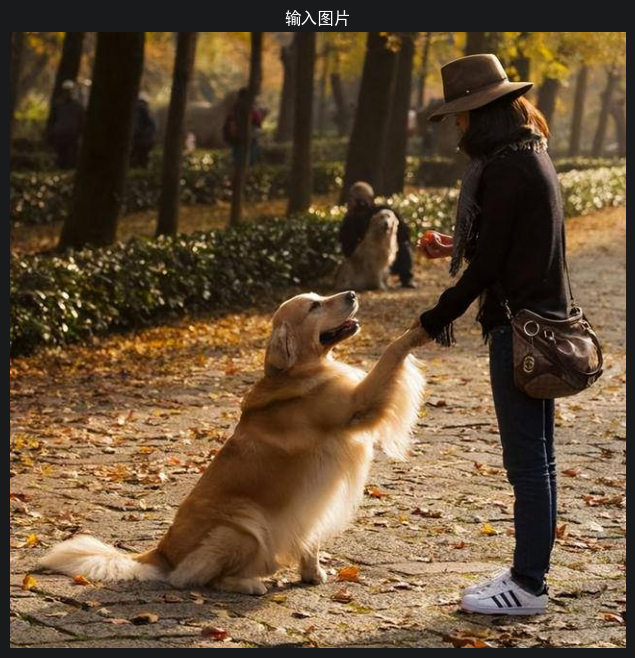

In [3]:
# 显示图片
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title('输入图片')
plt.show()

## 2. 加载中文CLIP模型和处理器

In [4]:
# 模型路径
model_path = "../code/chinese-clip-vit-base-patch16/"

print("正在加载CLIP模型...")
model = ChineseCLIPModel.from_pretrained(model_path)
# 明确指定use_fast=False消除警告，使用模型保存时的慢速processor
processor = ChineseCLIPProcessor.from_pretrained(model_path, use_fast=False)
print("模型加载完成!")

正在加载CLIP模型...
模型加载完成!


## 3. 定义零样本分类的候选标签

In [5]:
# 定义候选分类标签
candidate_labels = [
    "一只小狗",
    "一只猫", 
    "一只鸟",
    "一辆汽车",
    "一栋房子",
    "一棵树",
    "一束花",
    "一片草地"
]

print(f"候选分类标签: {candidate_labels}")

候选分类标签: ['一只小狗', '一只猫', '一只鸟', '一辆汽车', '一栋房子', '一棵树', '一束花', '一片草地']


## 4. 提取图像特征

In [6]:
print("提取图像特征...")
# 使用processor预处理图片
inputs = processor(images=img, return_tensors="pt")

# 推理模式，不计算梯度
with torch.inference_mode():
    # 获取图像特征
    image_features = model.get_image_features(**inputs)
    # 转换为numpy数组并L2归一化
    image_features = image_features.detach().numpy()
    image_features = normalize(image_features)

print(f"图像特征维度: {image_features.shape}")

提取图像特征...
图像特征维度: (1, 512)


## 5. 提取文本标签特征

In [7]:
print("提取文本标签特征...")
# 对所有候选标签进行预处理
text_inputs = processor(text=candidate_labels, return_tensors="pt", padding=True)

with torch.inference_mode():
    # 获取文本特征
    text_features = model.get_text_features(**text_inputs)
    # 转换为numpy数组并L2归一化
    text_features = text_features.detach().numpy()
    text_features = normalize(text_features)

print(f"文本特征维度: {text_features.shape}")

提取文本标签特征...
文本特征维度: (8, 512)


## 6. 计算相似度并得到分类结果

In [8]:
print("计算相似度，得到分类结果...")
# 计算图像特征与每个文本标签特征的点积相似度
similarities = np.dot(image_features, text_features.T)[0]

# 将相似度按从大到小排序
sorted_indices = similarities.argsort()[::-1]

计算相似度，得到分类结果...


## 7. 输出分类结果

In [9]:
print("\n" + "="*50)
print("Zero-Shot 分类结果:")
print("="*50)

for i, idx in enumerate(sorted_indices):
    label = candidate_labels[idx]
    score = similarities[idx]
    print(f"排名{i+1:2d}: {label:10s} -> 相似度得分: {score:.4f}")

print(f"\n结论: 模型预测这张图片是{candidate_labels[sorted_indices[0]]}")


Zero-Shot 分类结果:
排名 1: 一只小狗       -> 相似度得分: 0.3663
排名 2: 一只猫        -> 相似度得分: 0.3572
排名 3: 一只鸟        -> 相似度得分: 0.3540
排名 4: 一棵树        -> 相似度得分: 0.3380
排名 5: 一栋房子       -> 相似度得分: 0.3221
排名 6: 一片草地       -> 相似度得分: 0.3122
排名 7: 一辆汽车       -> 相似度得分: 0.3120
排名 8: 一束花        -> 相似度得分: 0.2902

结论: 模型预测这张图片是一只小狗


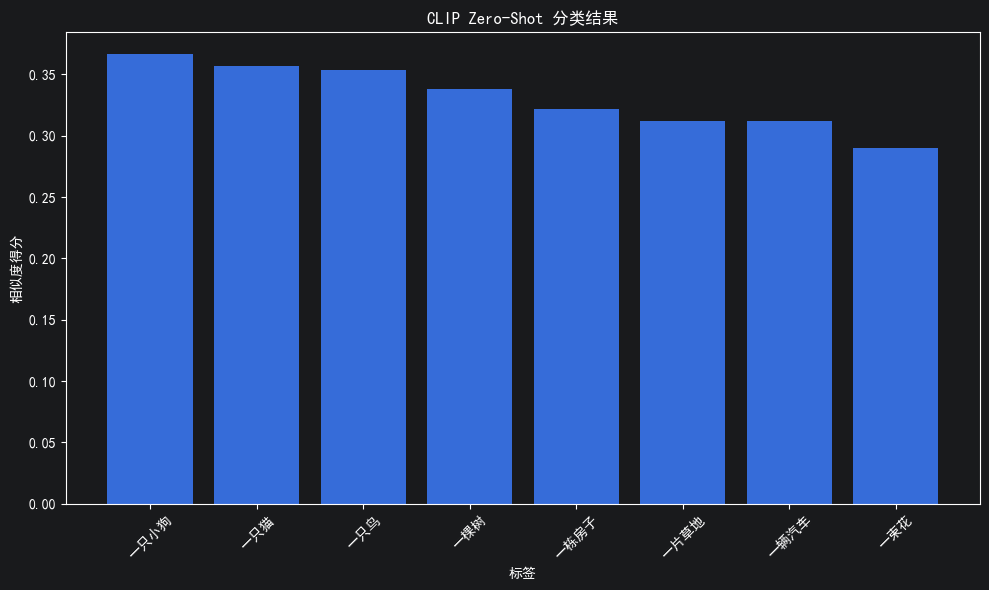

In [10]:
# 可视化结果
plt.figure(figsize=(10, 6))
plt.bar([candidate_labels[i] for i in sorted_indices], similarities[sorted_indices])
plt.xticks(rotation=45)
plt.xlabel('标签')
plt.ylabel('相似度得分')
plt.title('CLIP Zero-Shot 分类结果')
plt.tight_layout()
plt.show()